In [ ]:
import sys, os

sys.path.append(os.path.abspath(".."))

In [ ]:
import numpy as np
import random

np.random.seed(1337)
random.seed(1337)

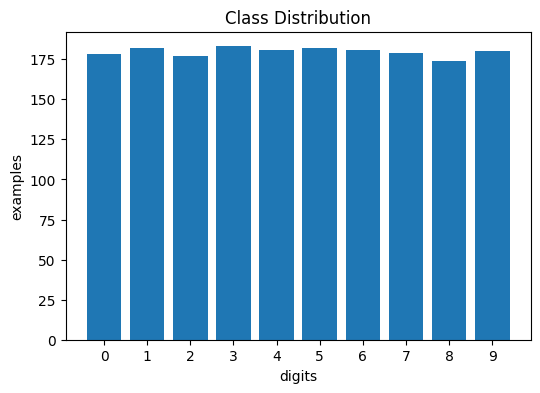

In [ ]:
# get the mnist dataset
from sklearn.datasets import load_digits
import numpy as np
import matplotlib.pyplot as plt


digits = load_digits()

# perform some eda
imgs, labels = digits.images, digits.target
counts = np.bincount(labels)

plt.figure(figsize=(6,4))
plt.bar(np.arange(len(counts)).astype(str), counts)
plt.xlabel("digits")
plt.ylabel("examples")
plt.title("Class Distribution")
plt.show()



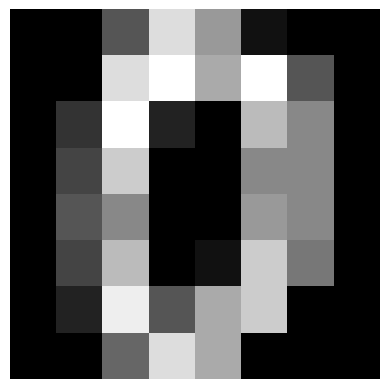

In [ ]:
plt.imshow(imgs[0], cmap='gray')
plt.axis('off');

In [ ]:
# preprocessing
images = imgs / 16.0
images = images - images.mean()

def pad32(x):
    out = np.zeros((32, 32))
    out[12:20, 12:20] = x
    return out

images = np.array([pad32(x) for x in images])
print(images.shape)  # (N, 32, 32)

(1797, 32, 32)


In [ ]:
# implement a simple lenet
from vectorgrad.engine import Tensor
from vectorgrad.nn import LeNet

def cross_entropy(logits, y):
    maxlog = logits.data.max()
    shifted = logits - maxlog
    logsumexp = (shifted.exp()).sum().log()
    return -(shifted[y] - logsumexp)


def loss_fn(model, X, y):
    losses = []
    correct = 0

    for xi, yi in zip(X, y):
        logits = model(Tensor(xi))
        losses.append(cross_entropy(logits, yi))

        correct += (np.argmax(logits.data) == yi)

    total_loss = sum(losses, Tensor(0.0))
    return total_loss * (1 / len(losses)), correct / len(losses)




In [ ]:
model = LeNet()
lr = 0.05

for epoch in range(501):
    model.zero_grad()

    loss, acc = loss_fn(model, images, labels)

    loss.backward()

    for p in model.parameters():
        p.data -= lr * p.grad

    if epoch % 50 == 0:
        print(f"epoch {epoch} loss {loss.data:.4f}, accuracy {acc*100:.2f}%")
